# Phase 1.2 — Dubins per-sample slack diagnostic

This **notebook is the single driver**: it sets every parameter in `PARAMS`, triggers the MATLAB per-sample slack SOP (`solve_dubins_slack.m`, which sets no parameters of its own — it only reads them from the environment), then loads the resulting per-sample slack table to (i) plot the slack distribution, (ii) locate the hard samples, and (iii) pick an effective bound $u_{\max}^{\rm eff}$ and the kept subset.

Self-contained: MATLAB runs with only `revision/matlab_frozen` + `revision/slack_diagnostic` on the path (never the main repo); the synthesis region is the Phase 1.1 `X_S_eff`; all I/O is under `revision/data/`.


## §0 — Per-sample slack SOP (what `solve_dubins_slack.m` solves)

Backstepping gives an output-feedback reach-avoid controller $u(\bm x) = A(\bm x)^{-1}\,b(\bm x; k_1)$ parameterized by the output-space map $k_1(\bm y)$. The bounded-control synthesis fixes $k_1$ by a sampled SOP. The **per-sample slack** variant probes a requested bound $\mathrm{ub}$ and reports, per state, how far the reach-avoid controller must exceed it.

Over $N$ valid reach-avoid samples $\{\bm x_j\}$ (safe, outside target, certificate $\ge 0$) and channels $i$:

$$
\min_{k_1,\,\delta\ge0,\,s_{j,i}\ge0}\quad \delta + w\sum_{j,i} s_{j,i}
$$

$$
\text{s.t.}\quad |u_i(\bm x_j)| \le \mathrm{ub}_i + s_{j,i}\quad(\text{soft, per sample}),
$$

$$
\underbrace{\nabla\psi\cdot k_1 - \lambda\,\psi + \delta - s_1\psi - s_2\,\text{target} \in \Sigma[\bm y]}_{\text{reach-avoid descent (hard, SOS)}},\qquad
\underbrace{M(\bm x_j)\succeq 0}_{\text{certificate (hard, per sample)}}.
$$

The reach-avoid property is kept **hard**; only the input bound is relaxed. The optimal slacks $s_{j,i}^\star$ form a **distribution**: the per-sample achievable bound is $\mathrm{ub}_i + s_{j,i}^\star$. Reading off a coverage quantile of this distribution gives the bound we can guarantee for that fraction of states, and which states to keep in the actual (Phase 1.3 hard) synthesis.


## §1 — Parameters (single source of truth) + MATLAB trigger helper

Edit `PARAMS` here to change anything; the values are pushed to MATLAB as environment variables. `solve_dubins_slack.m` errors if any is missing — there are no parameter defaults on the MATLAB side.


In [13]:
import json
import os
import shutil
import subprocess

import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# locate repo ROOT via revision/matlab_frozen (no reference to the main repo)
ROOT = os.path.abspath(os.getcwd())
for _ in range(6):
    if os.path.isdir(os.path.join(ROOT, "revision", "matlab_frozen")):
        break
    ROOT = os.path.dirname(ROOT)
REV = os.path.join(ROOT, "revision")
FROZEN = os.path.join(REV, "matlab_frozen")
SLACK_DIR = os.path.join(REV, "slack_diagnostic")
REV_DATA = os.path.join(REV, "data")
os.makedirs(REV_DATA, exist_ok=True)
MATLAB_BIN = shutil.which("matlab") or "/usr/local/bin/matlab"

# ============================ ALL PARAMETERS =============================
# Single source of truth. Anything the MATLAB solver needs is set here and
# pushed via ENV; solve_dubins_slack.m sets no parameter values.
PARAMS = {
    # --- (1) synthesis / SOP --------------------------------------------
    "mu": 0.1,  # backstepping certificate parameter (paper baseline)
    "xi0": 1e-8,  # SOS floor lambda >= xi0 for the vanilla k1 (descent rate)
    "ub": 5.0,  # requested (tight) input bound to probe; |u_i| <= ub + slack
    "n_valid_samples": 250,  # number of valid reach-avoid SOP samples
    "slack_weight": 100.0,  # weight w on sum of per-sample slacks in the objective
    "ds": 4,  # SOS auxiliary degree
    "dv": 4,  # k1 polynomial degree
    # --- (2) sampling ---------------------------------------------------
    "seed": 42,  # RNG seed for the reach-avoid sampler
    # --- (3) notebook-side selection (no MATLAB re-run needed) ----------
    "coverage_pct": 80,  # keep the lowest-q% of samples by combined slack
    "slack_floor": 1e-2,  # below this, slack is the solver's numerical zero
}
# Note: the modified Dubins car is kinematic (unicycle) -- it has NO physical
# constants to set (contrast the manipulator notebook's system-model group).

# Frozen example definition (read-only mirror of solve_dubins_slack.m).
# Documented here for completeness; NOT passed to MATLAB and NOT a tunable knob.
PROBLEM_DEF = {
    "state": "x = [x1, x2, theta, v]  (planar pose + heading + speed)",
    "inputs": "u = [omega, a]  (turn rate, acceleration)",
    "dynamics": "xdot = [v cos theta, v sin theta, omega, a]",
    "output": "y = [x1, x2]  (planar position)",
    "safe_set": "1e-3 * (-target_set + 300) * (-(y1^4+y2^4-16)(y1^4+y2^4-4)) >= 0",
    "target_set": "(y2)^2 + ((y1+1.7)/0.5)^2 - 0.4 <= 0",
}

ENV = {
    "MU": PARAMS["mu"],
    "XI0": PARAMS["xi0"],
    "UB": PARAMS["ub"],
    "N_VALID": PARAMS["n_valid_samples"],
    "SLACK_WEIGHT": PARAMS["slack_weight"],
    "DS": PARAMS["ds"],
    "DV": PARAMS["dv"],
    "SEED": PARAMS["seed"],
}


def run_matlab(script_name, env_overrides):
    """Run a revision MATLAB driver with ONLY the revision dirs on the path."""
    env = os.environ.copy()
    env.update({k: str(v) for k, v in env_overrides.items()})
    cmd = [
        MATLAB_BIN,
        "-batch",
        f"addpath('{FROZEN}'); addpath('{SLACK_DIR}'); "
        f"try, {script_name}; catch e, fprintf(2,'%s\\n',e.message); exit(1); end; exit(0);",
    ]
    import sys
    import time

    t0 = time.time()
    proc = subprocess.Popen(
        cmd,
        env=env,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        bufsize=1,
    )
    lines = []
    for raw in proc.stdout:  # stream MATLAB stdout live
        line = raw.rstrip()
        lines.append(line)
        print(f"[matlab +{time.time() - t0:6.0f}s] {line}")
        sys.stdout.flush()
    proc.wait()
    if proc.returncode != 0:
        raise RuntimeError(
            f"MATLAB {script_name} failed (rc={proc.returncode}); last lines:"
            + chr(10)
            + chr(10).join(lines[-20:])
        )
    return chr(10).join(lines)


print("ROOT       :", ROOT)
print("MATLAB_BIN :", MATLAB_BIN, "(exists:", os.path.exists(MATLAB_BIN), ")")
print("parameters (notebook is the single source of truth):")
for k, v in PARAMS.items():
    print(f"  {k:16s} = {v}")
print("frozen problem definition (mirrors solve_dubins_slack.m):")
for k, v in PROBLEM_DEF.items():
    print(f"  {k:11s}: {v}")

ROOT       : /Users/jianqiang/Downloads/reach_avoid_backstepping_MPC
MATLAB_BIN : /usr/local/bin/matlab (exists: True )
parameters (notebook is the single source of truth):
  mu               = 0.1
  xi0              = 1e-08
  ub               = 5.0
  n_valid_samples  = 250
  slack_weight     = 100.0
  ds               = 4
  dv               = 4
  seed             = 42
  coverage_pct     = 80
  slack_floor      = 0.01
frozen problem definition (mirrors solve_dubins_slack.m):
  state      : x = [x1, x2, theta, v]  (planar pose + heading + speed)
  inputs     : u = [omega, a]  (turn rate, acceleration)
  dynamics   : xdot = [v cos theta, v sin theta, omega, a]
  output     : y = [x1, x2]  (planar position)
  safe_set   : 1e-3 * (-target_set + 300) * (-(y1^4+y2^4-16)(y1^4+y2^4-4)) >= 0
  target_set : (y2)^2 + ((y1+1.7)/0.5)^2 - 0.4 <= 0


## §2 — Trigger the MATLAB per-sample slack SOP, then load the result

Re-runs MATLAB only when an output is missing or the cached `slack_meta_dubins.csv` was produced with different parameters (set `REGENERATE = True` to force). Outputs: `slack_persample_dubins.csv` (per-sample slacks + sample coords) and `slack_meta_dubins.csv` (probe params + summary).


In [14]:
PS_PATH = os.path.join(REV_DATA, "slack_persample_dubins.csv")
META_PATH = os.path.join(REV_DATA, "slack_meta_dubins.csv")
REGENERATE = False

# (PARAM key, meta column, tolerance) -- any change beyond tol re-runs MATLAB.
watched = [
    ("mu", "mu", 1e-9),
    ("xi0", "xi0", 1e-9),
    ("ub", "ub_req", 1e-9),
    ("n_valid_samples", "n_valid_samples", 0.5),
    ("slack_weight", "slack_weight", 1e-9),
    ("ds", "ds", 0.5),
    ("dv", "dv", 0.5),
    ("seed", "seed", 0.5),
]
need = REGENERATE or not (os.path.exists(PS_PATH) and os.path.exists(META_PATH))
if not need:
    cached = pd.read_csv(META_PATH).iloc[0]
    for pkey, ckey, tol in watched:
        if ckey not in cached.index:
            print(
                f"note: cached meta has no '{ckey}' (legacy) -> not forcing regenerate"
            )
            continue
        if abs(float(cached[ckey]) - float(PARAMS[pkey])) > tol:
            need = True
            print(f"cache miss on '{ckey}' -> regenerate")
            break

if need:
    print("running solve_dubins_slack.m (MATLAB) ...")
    out = run_matlab("solve_dubins_slack", ENV)
    print("\n".join(out.strip().splitlines()[-8:]))
else:
    print("cached outputs match PARAMS -> skipping MATLAB.")

df = pd.read_csv(PS_PATH)
meta = pd.read_csv(META_PATH).iloc[0]
UB_REQ = float(meta["ub_req"])  # symmetric: both channels share this bound

# per-channel RELATIVE slack + a combined (worst relative channel) score.
# omega and a share the same nominal bound, but we keep them separate so the
# effective bound is reported per channel (like the manipulator notebook).
df["rel1"] = df["slack1"] / UB_REQ
df["rel2"] = df["slack2"] / UB_REQ
df["rel"] = df[["rel1", "rel2"]].max(axis=1)

print(
    f"\nloaded {len(df)} samples; ub_req={UB_REQ:g} (both channels), "
    f"seed={int(meta['seed']) if 'seed' in meta.index else PARAMS['seed']}, "
    f"lambda={meta['lambda']:.4g}, delta={meta['delta']:.4g}"
)
for c, lab in [("slack1", "omega"), ("slack2", "a")]:
    s = df[c].values
    print(
        f"  {c} ({lab}): p50={np.percentile(s,50):.4g} p80={np.percentile(s,80):.4g} "
        f"p90={np.percentile(s,90):.4g} p95={np.percentile(s,95):.4g} max={s.max():.4g} "
        f"| nz(>1e-6)={100*np.mean(s>1e-6):.1f}%"
    )

note: cached meta has no 'seed' (legacy) -> not forcing regenerate
cached outputs match PARAMS -> skipping MATLAB.

loaded 250 samples; ub_req=5 (both channels), seed=42, lambda=1.095e-08, delta=152.3
  slack1 (omega): p50=0.002697 p80=2.625 p90=7.419 p95=13.34 max=32.93 | nz(>1e-6)=100.0%
  slack2 (a): p50=0.002695 p80=0.002697 p90=0.005504 p95=1.291 max=3.211 | nz(>1e-6)=100.0%


## §3 — Per-channel slack distributions

Row 1 = $\omega$, row 2 = $a$ (both share the symmetric nominal bound
$u_{\max}$). Histogram (log slack), sorted-slack elbow, and CDF with
effective-bound annotations $u_{\max}^{\rm eff}=u_{\max}+\text{quantile}$.


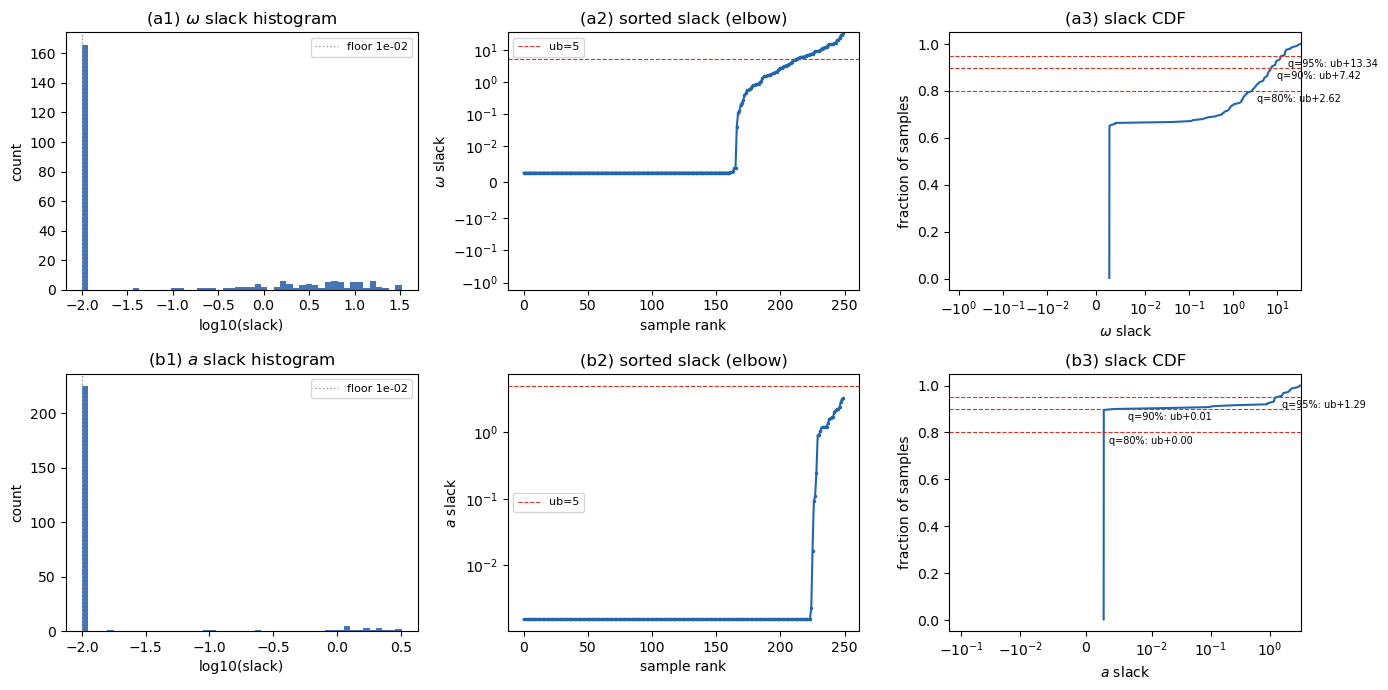

$\omega$: fraction with slack <= floor (1e-02): 66.4% (feasible at ub=5 with ~0 slack)
$a$: fraction with slack <= floor (1e-02): 90.0% (feasible at ub=5 with ~0 slack)


In [15]:
FLOOR = PARAMS["slack_floor"]
channels = [("slack1", UB_REQ, r"$\omega$"), ("slack2", UB_REQ, r"$a$")]

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for row, (col, ub, lab) in enumerate(channels):
    s = df[col].values
    s_sorted = np.sort(s)
    cdf = np.arange(1, len(s) + 1) / len(s)

    ax = axes[row, 0]
    ax.hist(np.log10(np.clip(s, FLOOR, None)), bins=50, color="#4575b4")
    ax.axvline(
        np.log10(FLOOR), color="#999999", ls=":", lw=1, label=f"floor {FLOOR:.0e}"
    )
    ax.set_xlabel("log10(slack)")
    ax.set_ylabel("count")
    ax.set_title(f"({chr(97+row)}1) {lab} slack histogram")
    ax.legend(fontsize=8)

    ax = axes[row, 1]
    ax.plot(np.arange(len(s)), s_sorted, ".-", ms=3, color="#2166ac")
    ax.axhline(ub, color="#d73027", ls="--", lw=0.8, label=f"ub={ub:g}")
    ax.set_xlabel("sample rank")
    ax.set_ylabel(f"{lab} slack")
    ax.set_title(f"({chr(97+row)}2) sorted slack (elbow)")
    ax.set_yscale("symlog", linthresh=FLOOR)
    ax.legend(fontsize=8)

    ax = axes[row, 2]
    ax.plot(s_sorted, cdf, color="#2166ac")
    for q in (0.8, 0.9, 0.95):
        thr = np.quantile(s, q)
        ax.axhline(q, color="#d73027", ls="--", lw=0.8)
        ax.annotate(
            f"q={q:.0%}: ub+{thr:.2f}",
            (thr, q),
            fontsize=7,
            xytext=(4, -8),
            textcoords="offset points",
        )
    ax.set_xlabel(f"{lab} slack")
    ax.set_ylabel("fraction of samples")
    ax.set_title(f"({chr(97+row)}3) slack CDF")
    ax.set_xscale("symlog", linthresh=FLOOR)
fig.tight_layout()
fig.savefig(
    os.path.join(REV_DATA, "slack_dubins_distribution.png"),
    dpi=130,
    bbox_inches="tight",
)
plt.show()

for col, ub, lab in channels:
    s = df[col].values
    print(
        f"{lab}: fraction with slack <= floor ({FLOOR:.0e}): {100*np.mean(s <= FLOOR):.1f}% "
        f"(feasible at ub={ub:g} with ~0 slack)"
    )

## §3.2 — Where are the hard samples?

Per channel, slack over $(x_1,x_2)$ and $(\theta,v)$. The bottom row checks
the FL-singularity hypothesis: slack vs $|v|$ (Dubins $\det A\propto v$,
singular at $v=0$) — hard samples should sit at small $|v|$.


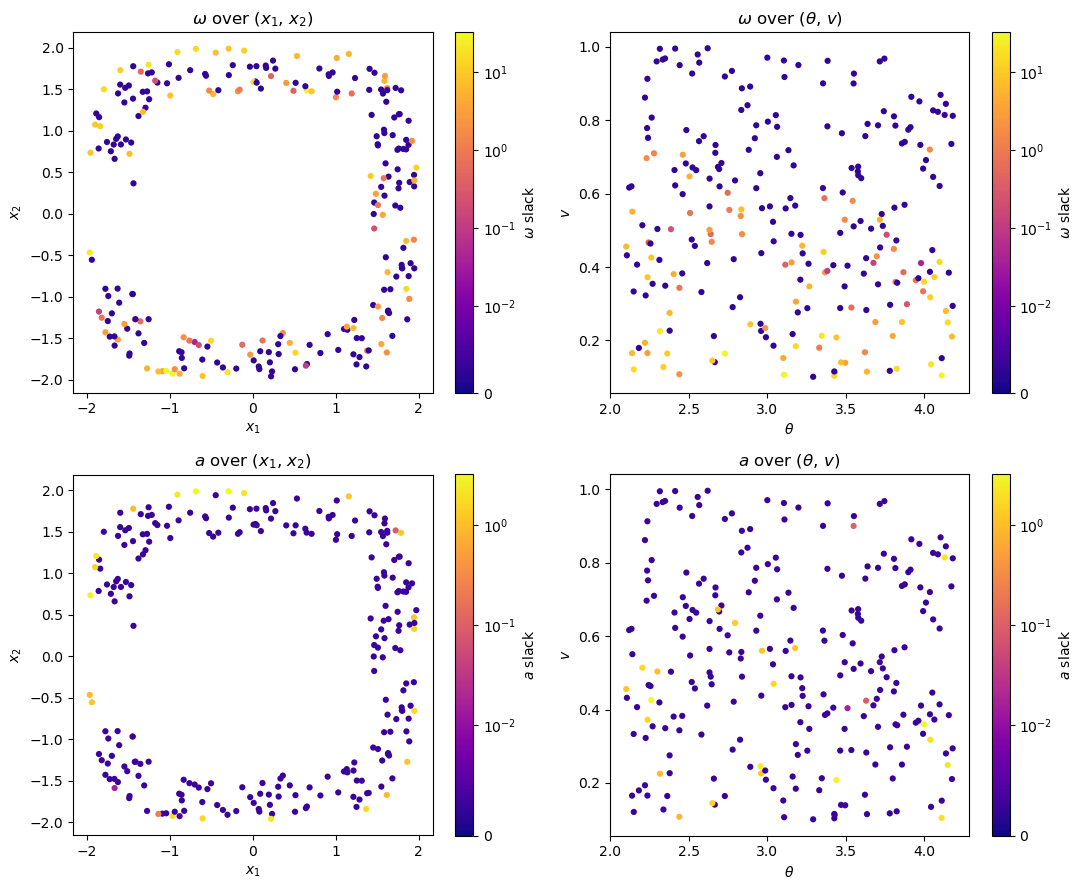

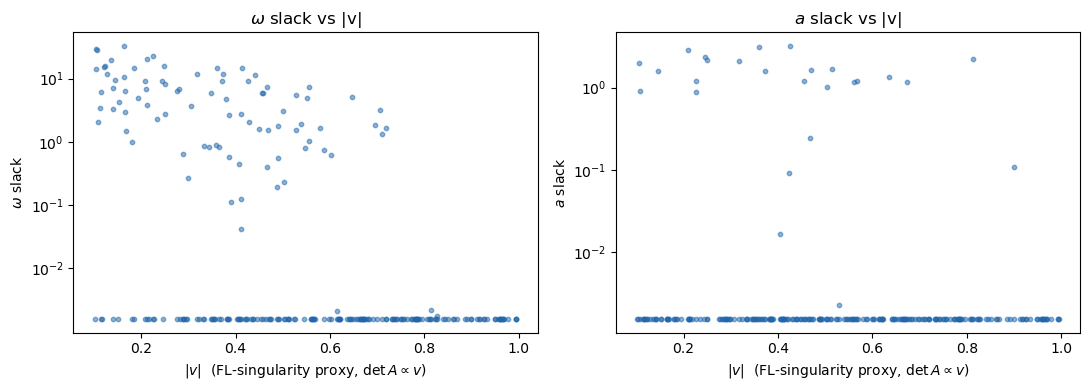

In [16]:
proj = [("x1", "x2", r"$x_1$", r"$x_2$"), ("th", "v", r"$\theta$", r"$v$")]

fig, axes = plt.subplots(2, 2, figsize=(11, 9))
for row, (col, ub, lab) in enumerate(channels):
    s = df[col].values
    norm = mcolors.SymLogNorm(
        linthresh=max(FLOOR, 1e-2), vmin=0, vmax=max(s.max(), FLOOR)
    )
    for k, (cx, cy, lx, ly) in enumerate(proj):
        ax = axes[row, k]
        sc = ax.scatter(
            df[cx], df[cy], c=s, cmap="plasma", norm=norm, s=20, edgecolors="none"
        )
        plt.colorbar(sc, ax=ax, label=f"{lab} slack")
        ax.set_xlabel(lx)
        ax.set_ylabel(ly)
        ax.set_title(f"{lab} over ({lx}, {ly})")
    axes[row, 0].set_aspect("equal")
fig.tight_layout()
fig.savefig(
    os.path.join(REV_DATA, "slack_dubins_spatial.png"), dpi=130, bbox_inches="tight"
)
plt.show()

# FL-singularity check: slack vs |v|  (Dubins det A propto v -> singular at v=0)
absv = np.abs(df["v"].values)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, (col, ub, lab) in zip(axes, channels):
    ax.scatter(absv, df[col], s=10, c="#2166ac", alpha=0.5)
    ax.set_xlabel(r"$|v|$  (FL-singularity proxy, $\det A \propto v$)")
    ax.set_ylabel(f"{lab} slack")
    ax.set_yscale("symlog", linthresh=max(FLOOR, 1e-2))
    ax.set_title(f"{lab} slack vs |v|")
fig.tight_layout()
fig.savefig(
    os.path.join(REV_DATA, "slack_dubins_vs_v.png"), dpi=130, bbox_inches="tight"
)
plt.show()

## §4 — Per-channel effective bounds (80th-pct slack, rounded up) + kept subset

For each channel we take the $80$th-percentile slack, **round it up to one
decimal place** ($s_i^{\rm thr}$), and set the effective bound
$u_i^{\rm eff}=u_{\max}+s_i^{\rm thr}$ — so both bounds carry at most one
decimal. A sample is **kept** iff both channels are within their rounded
thresholds ($s_{j,\omega}\le s_\omega^{\rm thr}$ and
$s_{j,a}\le s_a^{\rm thr}$); the rest are dropped.


coverage = 80%  (threshold = ceil-to-0.1 of the 80th pct slack)
kept 188 / 250  (75.2%);  dropped 62
  omega: s_thr = 2.7  ->  u_max_eff = 5 + 2.7 = 7.7  (slack/ub = 0.54 -> loose -> lower coverage or revisit region)
  a: s_thr = 0.1  ->  u_max_eff = 5 + 0.1 = 5.1  (slack/ub = 0.02 -> tight (~nominal))


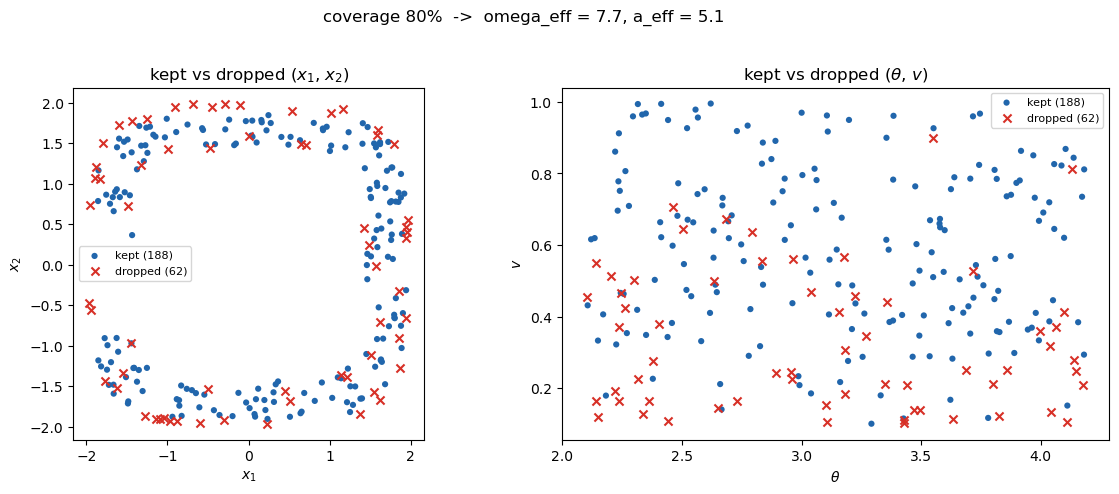

In [17]:
COVERAGE_PCT = PARAMS["coverage_pct"]


def ceil_1dp(x):
    """round UP to 1 decimal place (FP-robust)."""
    return float(np.ceil(round(x * 10.0, 6)) / 10.0)


# per-channel slack allowance: the COVERAGE_PCT-th percentile slack, rounded
# UP to 1 decimal place. This rounded value is BOTH the selection threshold
# and the increment added to the nominal bound, so the effective bounds carry
# at most 1 decimal place.
s_thr = {
    "omega": ceil_1dp(np.percentile(df["slack1"].values, COVERAGE_PCT)),
    "a": ceil_1dp(np.percentile(df["slack2"].values, COVERAGE_PCT)),
}
ub_eff = {
    "omega": round(UB_REQ + s_thr["omega"], 1),
    "a": round(UB_REQ + s_thr["a"], 1),
}
ratio = {
    "omega": (ub_eff["omega"] - UB_REQ) / UB_REQ,
    "a": (ub_eff["a"] - UB_REQ) / UB_REQ,
}

# kept = samples within BOTH per-channel rounded slack thresholds
keep_mask = (df["slack1"] <= s_thr["omega"]) & (df["slack2"] <= s_thr["a"])
kept = df[keep_mask].copy()
dropped = df[~keep_mask].copy()


def verdict(r):
    return (
        "tight (~nominal)"
        if r <= 0.05
        else "acceptable" if r <= 0.30 else "loose -> lower coverage or revisit region"
    )


print(
    f"coverage = {COVERAGE_PCT}%  (threshold = ceil-to-0.1 of the {COVERAGE_PCT}th pct slack)"
)
print(
    f"kept {len(kept)} / {len(df)}  ({100*len(kept)/len(df):.1f}%);  dropped {len(dropped)}"
)
for ch in ("omega", "a"):
    print(
        f"  {ch}: s_thr = {s_thr[ch]:.1f}  ->  u_max_eff = {UB_REQ:g} + {s_thr[ch]:.1f} = {ub_eff[ch]:.1f}  "
        f"(slack/ub = {ratio[ch]:.2f} -> {verdict(ratio[ch])})"
    )

proj_keep = [("x1", "x2", r"$x_1$", r"$x_2$"), ("th", "v", r"$\theta$", r"$v$")]
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
for ax, (cx, cy, lx, ly) in zip(axes, proj_keep):
    ax.scatter(
        kept[cx],
        kept[cy],
        s=20,
        c="#2166ac",
        label=f"kept ({len(kept)})",
        edgecolors="none",
    )
    ax.scatter(
        dropped[cx],
        dropped[cy],
        s=34,
        c="#d73027",
        marker="x",
        label=f"dropped ({len(dropped)})",
    )
    ax.set_xlabel(lx)
    ax.set_ylabel(ly)
    ax.legend(fontsize=8)
    ax.set_title(f"kept vs dropped ({lx}, {ly})")
axes[0].set_aspect("equal")
fig.suptitle(
    f"coverage {COVERAGE_PCT}%  ->  omega_eff = {ub_eff['omega']:.1f}, a_eff = {ub_eff['a']:.1f}",
    y=1.02,
)
fig.tight_layout()
fig.savefig(
    os.path.join(REV_DATA, "slack_dubins_kept.png"), dpi=130, bbox_inches="tight"
)
plt.show()

## §5 — Export Phase 1.2 outputs

`kept_samples_dubins.csv` (subset for Phase 1.3) and `phase1_2_outputs_dubins.json` (`u_max_eff`, coverage, threshold, probe params).


In [18]:
kept_path = os.path.join(REV_DATA, "kept_samples_dubins.csv")
kept[["sample_idx", "x1", "x2", "th", "v", "slack1", "slack2"]].to_csv(
    kept_path, index=False
)

out = {
    "phase": "1.2",
    "example": "dubins",
    "self_contained": True,
    "probe": {
        "mu": float(meta["mu"]),
        "xi0": float(meta["xi0"]),
        "ub_req": UB_REQ,
        "slack_weight": float(meta["slack_weight"]),
        "ds": float(meta["ds"]),
        "dv": float(meta["dv"]),
        "seed": int(meta["seed"]) if "seed" in meta.index else PARAMS["seed"],
        "lambda": float(meta["lambda"]),
        "delta": float(meta["delta"]),
        "n_samples": int(len(df)),
    },
    "coverage_pct": COVERAGE_PCT,
    "slack_threshold": s_thr,
    "u_max_eff": ub_eff,
    "u_max_eff_over_ub_req": {
        "omega": ub_eff["omega"] / UB_REQ,
        "a": ub_eff["a"] / UB_REQ,
    },
    "n_kept": int(len(kept)),
    "n_dropped": int(len(dropped)),
    "kept_samples_csv": os.path.relpath(kept_path, ROOT),
    "slack_quantiles": {
        "omega": {
            q: float(np.percentile(df["slack1"], q)) for q in (50, 80, 90, 95, 99)
        },
        "a": {q: float(np.percentile(df["slack2"], q)) for q in (50, 80, 90, 95, 99)},
    },
    "notes": (
        "Per-sample, per-channel slack SOP at the symmetric bound ub_req; kept subset chosen by "
        "the combined relative slack rho = max(s_omega, s_a)/ub_req <= q-quantile. Per-channel "
        "u_max_eff_i = ub_req + max(slack_i) over the kept subset feeds the Phase 1.3 hard SOP. "
        "MATLAB solver may report approximate (near-boundary) status; slacks used for bound "
        "selection only."
    ),
}
out_path = os.path.join(REV_DATA, "phase1_2_outputs_dubins.json")
with open(out_path, "w") as fh:
    json.dump(out, fh, indent=2)
print(f"wrote {kept_path}  ({len(kept)} rows)")
print(f"wrote {out_path}")
print(json.dumps(out, indent=2))

wrote /Users/jianqiang/Downloads/reach_avoid_backstepping_MPC/revision/data/kept_samples_dubins.csv  (188 rows)
wrote /Users/jianqiang/Downloads/reach_avoid_backstepping_MPC/revision/data/phase1_2_outputs_dubins.json
{
  "phase": "1.2",
  "example": "dubins",
  "self_contained": true,
  "probe": {
    "mu": 0.1,
    "xi0": 1e-08,
    "ub_req": 5.0,
    "slack_weight": 100.0,
    "ds": 4.0,
    "dv": 4.0,
    "seed": 42,
    "lambda": 1.09456316972482e-08,
    "delta": 152.342330461502,
    "n_samples": 250
  },
  "coverage_pct": 80,
  "slack_threshold": {
    "omega": 2.7,
    "a": 0.1
  },
  "u_max_eff": {
    "omega": 7.7,
    "a": 5.1
  },
  "u_max_eff_over_ub_req": {
    "omega": 1.54,
    "a": 1.02
  },
  "n_kept": 188,
  "n_dropped": 62,
  "kept_samples_csv": "revision/data/kept_samples_dubins.csv",
  "slack_quantiles": {
    "omega": {
      "50": 0.00269702548332955,
      "80": 2.624731743278106,
      "90": 7.41900069093288,
      "95": 13.344240498149091,
      "99": 25.5422